In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

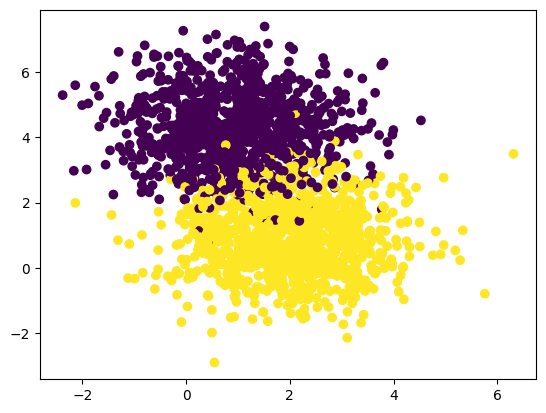

In [2]:
#Generate dataset
X , y = make_blobs(n_samples=2000, n_features=2, centers=2, cluster_std=1.12, random_state=0)
n_features = 2
# print(X.shape,y.shape)

#Visualise Dataset
def Visualise(X,y):
    plt.scatter(X[:,0] , X[:,1] , c=y , cmap="viridis")
    plt.show()

Visualise(X,y)

In [3]:
#Normalise Dataset
def Normalise(X):
    u = X.mean(axis=0)
    std = X.std(axis=0)
    return (X-u)/std
X = Normalise(X)

In [4]:
#Test Split
XT , Xt , yT , yt = train_test_split(X,y,test_size=0.25, random_state=0, shuffle=False)
yT = yT.reshape(-1,1)
yt = yt.reshape(-1,1)

In [5]:
#Modelling
def Sigmoid(z):
    return 1/(1+np.exp(-z))

def Hypothesis(X,theta):
    return Sigmoid(np.dot(X,theta))

def AddBias(X):
    m = X.shape[0]
    if np.all(X[:, 0] == 1):
        return X
    else:
        ones = np.ones((m, 1))
        X = np.hstack((ones, X))
    return X

XT = AddBias(XT)
Xt = AddBias(Xt)

def LossFunction(y, yp):
    epsilon = 1e-8
    m = y.shape[0]
    loss = -np.mean(y * np.log(yp + epsilon) + (1 - y) * np.log(1 - yp + epsilon))
    return loss

def GradientComputation(X,y,yp):
    m = X.shape[0]
    grad = -np.dot(X.T,(y-yp))
    return grad/m

def Train(X,y,max_iters=1000,learning_rate=0.2):
    theta = np.random.randn(X.shape[1], 1)
    error_list = []
    for i in range(max_iters):
        yp = Hypothesis(X,theta)
        e = LossFunction(y,yp)
        error_list.append(e)
        grad = GradientComputation(X,y,yp)
        theta = theta - learning_rate*grad
    plt.plot(error_list)
    plt.show()
    return theta

In [6]:
def Predictions(X,theta):
    yp = Hypothesis(X,theta)
    preds = np.zeros((X.shape[0],1), dtype = int)
    preds[yp > 0.5] = 1
    return preds

def Accuracy(X,y,theta):
    preds = Predictions(X,theta)
    return (((y==preds).sum())/y.shape[0])*100

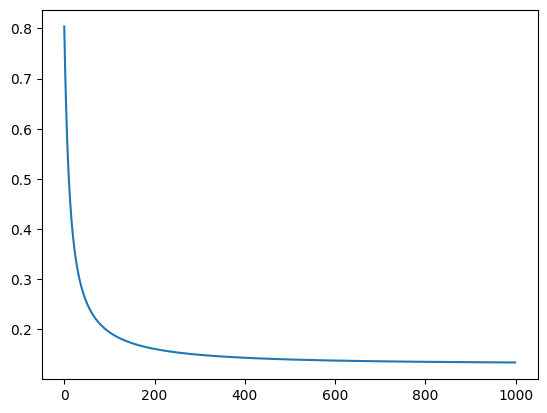

In [7]:
theta = Train(XT,yT)

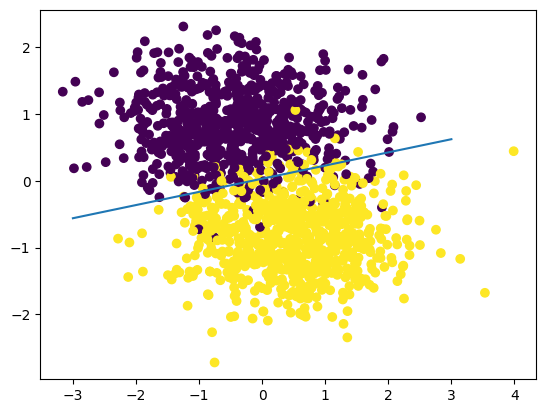

94.86666666666666
94.19999999999999


In [8]:
#Boundary Line
plt.scatter(XT[:,1],XT[:,2],c=yT,cmap="viridis")
x1 = np.linspace(-3,3,6)
x2 = -(theta[0][0] + theta[1][0]*x1)/theta[2][0]
plt.plot(x1,x2)
plt.show()

print(Accuracy(XT,yT,theta))
print(Accuracy(Xt,yt,theta))